In [1]:
# IMPORTING CORE LIBRARIES

import numpy as np
import pandas as pd
from pathlib import Path    # for saving to folder sand reading from folders

In [2]:
# FOR VISUALIZATIONS
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#FOR PREPROCESSING
from sklearn.preprocessing import ( OneHotEncoder, MinMaxScaler)

#FOR PIPELINE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [4]:
# FOR MODELS - RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor

In [5]:
# FOR METRICS
from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score)

In [187]:
RANDOM_STATE = 42       # setting random state
FORECAST_HORIZON = 3    # 3 month forecast

In [7]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

In [8]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "state_level_features_3month_forecast.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

In [9]:
df.sample(5)

,state,date,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,is_anomaly,quarter,target,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,month,year
1904,uttarakhand,2018-06-01,rice,30157.58,184.38,25288.36,0,2,32522.13,20753.05,20753.05,17621.60,19709.233333,1807.943501,6,2018
1955,uttarakhand,2019-07-01,wheat,25381.21,1904.24,9735.75,0,3,25303.82,25913.44,25910.56,25934.49,25919.496667,13.064253,7,2019
371,dadra and nagar haveli and daman and diu,2019-08-01,rice,1023.47,968.20,0.00,0,3,1028.53,1020.49,1018.77,1017.08,1018.780000,1.704954,8,2019
1058,kerala,2021-03-01,rice,75676.37,69095.10,83.83,0,1,75628.44,74883.38,74988.14,75203.82,75025.113333,163.388245,3,2021
1128,lakshadweep,2019-01-01,rice,131.23,40.14,0.00,0,1,132.36,131.92,131.97,131.93,131.940000,0.021551,1,2019


In [10]:
df.head()

,state,date,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,is_anomaly,quarter,target,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,month,year
0,andaman and nicobar islands,2018-01-01,rice,101.71,1220.90,0.00,0,1,407.87,101.67,100.21,0.10,67.326667,58.224578,1,2018
1,andaman and nicobar islands,2018-02-01,rice,116.73,13.70,0.00,0,1,414.05,101.71,101.67,100.21,101.196667,0.854712,2,2018
2,andaman and nicobar islands,2018-03-01,rice,116.19,7.17,0.00,0,1,429.04,116.73,101.71,101.67,106.703333,8.683371,3,2018
3,andaman and nicobar islands,2018-04-01,rice,407.87,12.97,180.92,0,2,436.08,116.19,116.73,101.71,111.543333,8.520196,4,2018
4,andaman and nicobar islands,2018-05-01,rice,414.05,40.12,169.25,0,2,423.13,407.87,116.19,116.73,213.596667,168.245859,5,2018


In [11]:
df["date"].agg(["min", "max"])

min   2017-04-01
max   2021-07-01
Name: date, dtype: datetime64[ns]

In [12]:
df["is_anomaly"].value_counts()

is_anomaly
0    1881
1     171
Name: count, dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2052 entries, 0 to 2051
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   state                   2052 non-null   object        
 1   date                    2052 non-null   datetime64[ns]
 2   commodity               2052 non-null   object        
 3   total_allocated_qty     2052 non-null   float64       
 4   epos_allocated_qty      2052 non-null   float64       
 5   not_epos_allocated_qty  2052 non-null   float64       
 6   is_anomaly              2052 non-null   int64         
 7   quarter                 2052 non-null   int64         
 8   target                  2052 non-null   float64       
 9   lag_1                   2052 non-null   float64       
 10  lag_2                   2052 non-null   float64       
 11  lag_3                   2052 non-null   float64       
 12  rolling_mean_3          2052 non-null   float64 

In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,2052,2019-08-28 02:28:04.210526464,2017-04-01 00:00:00,2018-10-01 00:00:00,2019-09-01 00:00:00,2020-07-01 00:00:00,2021-07-01 00:00:00,NaN
total_allocated_qty,2052.0,120319.466974,0.0,8656.975,40874.405,162353.5575,2128547.56,183977.481573
epos_allocated_qty,2052.0,62558.943952,0.0,242.3725,12846.48,114954.2525,465572.54,87969.140558
not_epos_allocated_qty,2052.0,20005.184581,0.0,0.0,801.995,7277.0525,1479999.55,68333.419345
is_anomaly,2052.0,0.083333,0.0,0.0,0.0,0.0,1.0,0.276453
quarter,2052.0,2.402047,1.0,1.0,2.0,3.0,4.0,1.121857
target,2052.0,116784.547437,0.0,9078.1875,41372.21,160188.905,1457334.74,171612.202974
lag_1,2052.0,119629.730521,0.0,8212.83,39868.615,160565.76,2128547.56,183942.050331
lag_2,2052.0,118653.287734,0.0,7632.13,34177.59,160143.1025,2128547.56,184244.582285
lag_3,2052.0,116884.849493,0.0,7117.335,30000.68,157758.88,2128547.56,184337.612724


In [15]:
""" 
Rationale for commodity-specific panel completeness thresholds:
Rice is a national staple under India's PDS and is allocated across almost all states and UTs, so high geographic coverage is expected in monthly data.
Wheat, however, is a regional staple concentrated largely in North and Central India, and many southern and north-eastern states legitimately report zero or no wheat allocations.
Therefore, panel completeness thresholds are defined separately by commodity to reflect this structural policy reality rather than treating missing state-commodity combinations as data errors.
"""

" \nRationale for commodity-specific panel completeness thresholds:\nRice is a national staple under India's PDS and is allocated across almost all states and UTs, so high geographic coverage is expected in monthly data.\nWheat, however, is a regional staple concentrated largely in North and Central India, and many southern and north-eastern states legitimately report zero or no wheat allocations.\nTherefore, panel completeness thresholds are defined separately by commodity to reflect this structural policy reality rather than treating missing state-commodity combinations as data errors.\n"

In [16]:
EXPECTED_STATES = 36        # 28 states + 8 UTs

COMMODITY_THRESHOLDS = {
    "rice": 0.70,   # national staple
    "wheat": 0.50   # regional staple
}


In [17]:
# creating absolute thresholds for states based on commodity
commodity_state_thresholds = {
    commodity: int(round(threshold * EXPECTED_STATES))
    for commodity, threshold in COMMODITY_THRESHOLDS.items()
}

commodity_state_thresholds

{'rice': 25, 'wheat': 18}

In [18]:
panel_counts = (
    df
    .groupby(["date", "commodity"])["state"]
    .nunique()
    .reset_index(name="num_states_reported")
)

In [19]:
# CHECKING
panel_counts.sample(10)

,date,commodity,num_states_reported
11,2017-09-01,wheat,1
45,2019-02-01,wheat,20
38,2018-11-01,rice,30
52,2019-06-01,rice,29
78,2020-07-01,rice,30
19,2018-01-01,wheat,16
27,2018-05-01,wheat,20
67,2020-01-01,wheat,22
55,2019-07-01,wheat,21
26,2018-05-01,rice,30


In [20]:
# CREATE AN IS_VALID_DATA FLAG
def is_valid_row(row):
    threshold = commodity_state_thresholds.get(row["commodity"])
    return row["num_states_reported"] >= threshold

panel_counts["is_valid_data"] = panel_counts.apply(is_valid_row, axis=1)


In [21]:
# CHECKING
panel_counts["is_valid_data"].value_counts()

is_valid_data
True     74
False    30
Name: count, dtype: int64

In [22]:
# CHECKING BY COMMODITY
panel_counts.groupby("commodity")["is_valid_data"].value_counts()

commodity  is_valid_data
rice       True             37
           False            15
wheat      True             37
           False            15
Name: count, dtype: int64

In [23]:
# CHECKING THE BEGINNING TRAIL
panel_counts.sort_values("date").head(10)

,date,commodity,num_states_reported,is_valid_data
0,2017-04-01,rice,2,False
1,2017-04-01,wheat,1,False
2,2017-05-01,rice,2,False
3,2017-05-01,wheat,1,False
4,2017-06-01,rice,2,False
5,2017-06-01,wheat,1,False
6,2017-07-01,rice,2,False
7,2017-07-01,wheat,1,False
8,2017-08-01,rice,2,False
9,2017-08-01,wheat,1,False


In [24]:
# CHECKING THE TAIL
panel_counts.sort_values("date").tail(10)

,date,commodity,num_states_reported,is_valid_data
94,2021-03-01,rice,31,True
95,2021-03-01,wheat,20,True
96,2021-04-01,rice,29,True
97,2021-04-01,wheat,20,True
98,2021-05-01,rice,29,True
99,2021-05-01,wheat,19,True
100,2021-06-01,rice,23,False
101,2021-06-01,wheat,15,False
102,2021-07-01,rice,1,False
103,2021-07-01,wheat,1,False


In [25]:
# EXPLICITLY CHECKING JULY 2021 - AS IT IS THE TRAILING END OF DATA
panel_counts[
    panel_counts["date"] == "2021-07-01"
].sort_values("commodity")


,date,commodity,num_states_reported,is_valid_data
102,2021-07-01,rice,1,False
103,2021-07-01,wheat,1,False


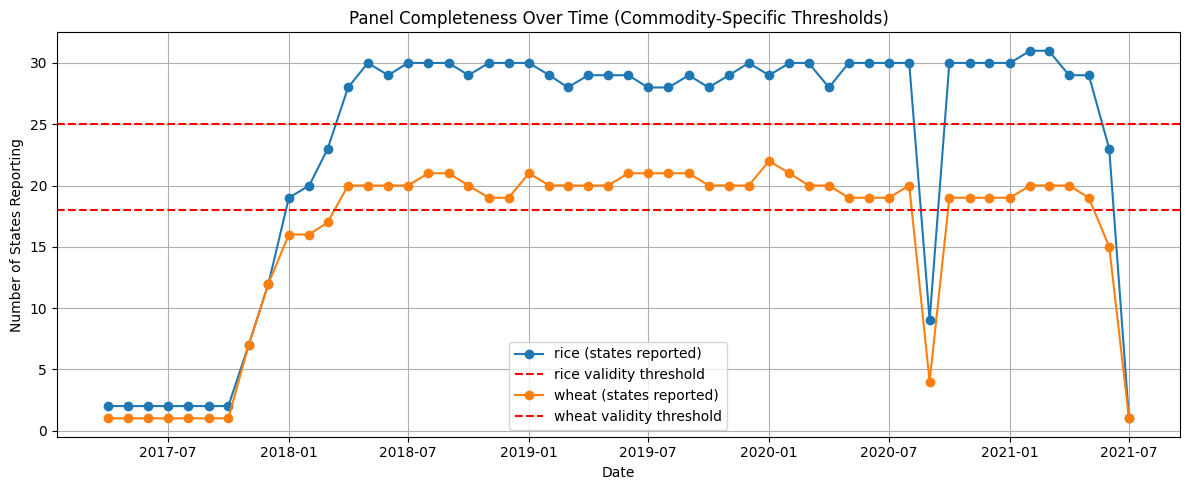

In [26]:
# VISUALISING PANEL COMPLETENESS (HOW MANY STATES/U/T REPORTED FOR EACH COMMODITY) OVER TIME
plt.figure(figsize=(12, 5))

for commodity in panel_counts["commodity"].unique():
    subset = panel_counts[panel_counts["commodity"] == commodity]
    
    plt.plot(
        subset["date"],
        subset["num_states_reported"],
        marker="o",
        label=f"{commodity} (states reported)"
    )
    
    plt.axhline(
        y=commodity_state_thresholds[commodity],
        linestyle="--",
        color='red',
        label=f"{commodity} validity threshold"
    )

plt.title("Panel Completeness Over Time (Commodity-Specific Thresholds)")
plt.xlabel("Date")
plt.ylabel("Number of States Reporting")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
# MERGE THE FLAGS ONTO THE DATAFRAME
df = df.merge(
    panel_counts[["date", "commodity", "is_valid_data"]],
    on=["date", "commodity"],
    how="left"
)
df["is_valid_data"] = df["is_valid_data"].fillna(False)

In [28]:
df[["is_anomaly", "is_valid_data"]].value_counts()

is_anomaly  is_valid_data
0           True             1730
            False             151
1           True               99
            False              72
Name: count, dtype: int64

In [29]:
df.isna().sum()

state                     0
date                      0
commodity                 0
total_allocated_qty       0
epos_allocated_qty        0
not_epos_allocated_qty    0
is_anomaly                0
quarter                   0
target                    0
lag_1                     0
lag_2                     0
lag_3                     0
rolling_mean_3            0
rolling_std_3             0
month                     0
year                      0
is_valid_data             0
dtype: int64

In [30]:
df.columns

Index(['state', 'date', 'commodity', 'total_allocated_qty',
       'epos_allocated_qty', 'not_epos_allocated_qty', 'is_anomaly', 'quarter',
       'target', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3',
       'month', 'year', 'is_valid_data'],
      dtype='object')

In [31]:
# REORDERING COLUMNS
desired_column_order = [
    "state",
    "date",
    "month",
    "year",
    "quarter",
    "is_anomaly",
    "is_valid_data",
    "commodity",
    "total_allocated_qty",
    "epos_allocated_qty",
    "not_epos_allocated_qty",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_std_3",
    "target"
]

In [32]:
existing_cols = [c for c in desired_column_order if c in df.columns]
df = df[existing_cols]

In [33]:
df.head(2)

,state,date,month,year,quarter,is_anomaly,is_valid_data,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,target
0,andaman and nicobar islands,2018-01-01,1,2018,1,0,False,rice,101.71,1220.9,0.0,101.67,100.21,0.10,67.326667,58.224578,407.87
1,andaman and nicobar islands,2018-02-01,2,2018,1,0,False,rice,116.73,13.7,0.0,101.71,101.67,100.21,101.196667,0.854712,414.05


In [34]:
df.tail(2)

,state,date,month,year,quarter,is_anomaly,is_valid_data,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,target
2050,west bengal,2021-05-01,5,2021,2,0,True,wheat,196183.94,191873.02,78.8,195543.54,194360.02,195956.01,195286.523333,828.455911,65951.02
2051,west bengal,2021-06-01,6,2021,2,0,False,wheat,196462.84,190994.96,78.8,196183.94,195543.54,194360.02,195362.500000,925.339210,66977.75


In [35]:
OUTPUT_PATH = PROCESSED_PATH / "data_for_model_with_validation_flags.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved dataset with validation flags to: {OUTPUT_PATH}")
print("Shape:", df.shape)

Saved dataset with validation flags to: e:\Learning\Data Science\ML Project\pds_foodgrain_forecasting\data\processed\data_for_model_with_validation_flags.csv
Shape: (2052, 17)


In [ ]:
# ---------------------------------------------------
#  REVISED TRAINING AND VALIDATION DATA SPLIT
# ---------------------------------------------------

In [36]:
# FILTERING USABLE ROWS
USABLE_MASK = (df["is_anomaly"] == 0) & (df["is_valid_data"] == True)

df_usable = (
    df[USABLE_MASK]
    .sort_values(["state", "commodity", "date"])
    .reset_index(drop=True)
)

In [37]:
df_usable["date"].agg(["min", "max"])


min   2018-04-01
max   2021-05-01
Name: date, dtype: datetime64[ns]

In [39]:
# IDENTIFYING VALID MONTHS
valid_months = (
    df_usable[["date"]]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

valid_months.head(10)

,date
0,2018-04-01
1,2018-05-01
2,2018-06-01
3,2018-07-01
4,2018-08-01
5,2018-09-01
6,2018-10-01
7,2018-11-01
8,2018-12-01
9,2019-01-01


In [40]:
valid_months.tail(10)

,date
25,2020-05-01
26,2020-06-01
27,2020-07-01
28,2020-11-01
29,2020-12-01
30,2021-01-01
31,2021-02-01
32,2021-03-01
33,2021-04-01
34,2021-05-01


In [41]:
FORECAST_HORIZON = 3

validation_months = valid_months["date"].iloc[-FORECAST_HORIZON:].tolist()
validation_months

[Timestamp('2021-03-01 00:00:00'),
 Timestamp('2021-04-01 00:00:00'),
 Timestamp('2021-05-01 00:00:00')]

In [ ]:
validation_start_date = min(validation_months)
train_end_date = validation_start_date - pd.DateOffset(months=FORECAST_HORIZON)
validation_start_date, train_end_date

(Timestamp('2021-03-01 00:00:00'), Timestamp('2020-12-01 00:00:00'))

In [47]:
# SPLITTING INTO TRAINING DATA

train_df = (
    df_usable[df_usable["date"] < train_end_date]
    .sort_values(["state", "commodity", "date"])
    .reset_index(drop=True)
)

In [48]:
# SPLITTING INTO VALIDATION DATA

val_df = (
    df_usable[df_usable["date"].isin(validation_months)]
    .sort_values(["state", "commodity", "date"])
    .reset_index(drop=True)
)

In [49]:
# LEAKAGE CHECK
latest_train_target_date = (
    train_df["date"] + pd.DateOffset(months=FORECAST_HORIZON)
).max()

earliest_val_feature_date = val_df["date"].min()

print("Latest train target date :", latest_train_target_date)
print("Earliest val feature date:", earliest_val_feature_date)

Latest train target date : 2021-02-01 00:00:00
Earliest val feature date: 2021-03-01 00:00:00


In [50]:
# SIZE CHECKS
print("Train date range:", train_df["date"].min(), "→", train_df["date"].max())
print("Val date range  :", val_df["date"].min(), "→", val_df["date"].max())

print("Train rows:", train_df.shape[0])
print("Val rows  :", val_df.shape[0])

Train date range: 2018-04-01 00:00:00 → 2020-11-01 00:00:00
Val date range  : 2021-03-01 00:00:00 → 2021-05-01 00:00:00
Train rows: 1433
Val rows  : 148


In [51]:
# ----------------------------------------
# DEFINING TARGET AND FEATURES
# ----------------------------------------

In [52]:

TARGET_COL = "target"

NUMERIC_FEATURES = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_std_3",
    "month",
    "quarter",
]
CATEGORICAL_FEATURES = [
    "state",
    "commodity",
]
# check:
set(NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COL]).issubset(train_df.columns)

True

In [53]:
X_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_df[TARGET_COL]

X_val = val_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_val = val_df[TARGET_COL]

In [54]:
X_train.shape

(1433, 9)

In [55]:
y_train.shape

(1433,)

In [56]:
X_val.shape

(148, 9)

In [57]:
y_val.shape

(148,)

In [58]:
# ---------------------------------------
# REBUILDING PREPROCESSING PIPELINE
# ---------------------------------------

In [59]:
# Numeric processing
# Random Forest Doesn't require Normalisation
numeric_transformer = Pipeline(
    steps=[
        ("passthrough", "passthrough")
    ]
)

In [60]:
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [61]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop"
)

In [62]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

X_train_processed.shape


(1433, 42)

In [63]:
X_val_processed.shape

(148, 42)

In [188]:
# DEFINING THE MODEL

rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [189]:
# BUILDING PIPELINE
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

In [190]:
# TRAIN MODEL ON CLEAN DATA
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [191]:
# PREDICT USING THE MODEL
y_val_pred = rf_pipeline.predict(X_val)

In [192]:
# ----------------------------
# PERFORMANCE EVALUATION
# ----------------------------

In [193]:
mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape = safe_mape(y_val, y_val_pred)


In [194]:
print(f"Validation MAE  : {mae:,.2f}")
print(f"Validation RMSE : {rmse:,.2f}")
print(f"Validation R²   : {r2:.3f}")
print(f"Validation MAPE : {mape:.2f}%")

Validation MAE  : 34,462.23
Validation RMSE : 66,709.64
Validation R²   : 0.676
Validation MAPE : 95.47%


In [195]:
y_naive = X_val["lag_3"]

baseline_mae = mean_absolute_error(y_val, y_naive)
baseline_rmse = np.sqrt(mean_squared_error(y_val, y_naive))

print("Naive Baseline MAE :", baseline_mae)
print("Naive Baseline RMSE:", baseline_rmse)

Naive Baseline MAE : 26240.608986486484
Naive Baseline RMSE: 54611.175034444736


In [196]:
# VISUALISATION OF PREDICTED VS ACTUAL

val_results = val_df.copy()

val_results["y_true"] = y_val.values
val_results["y_pred"] = y_val_pred
val_results["y_naive"] = X_val["lag_3"].values

val_results.head()

,state,date,month,year,quarter,is_anomaly,is_valid_data,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,target,y_true,y_pred,y_naive
0,andaman and nicobar islands,2021-03-01,3,2021,1,0,True,rice,401.85,221.97,0.00,292.05,24.40,575.96,297.470000,275.819943,316.04,316.04,371.980195,575.96
1,andhra pradesh,2021-03-01,3,2021,1,0,True,rice,152838.62,139070.55,0.00,152838.62,153114.83,153377.37,153110.273333,269.403903,150269.11,150269.11,151761.545423,153377.37
2,andhra pradesh,2021-04-01,4,2021,2,0,True,rice,153318.35,141209.69,0.00,152838.62,152838.62,153114.83,152930.690000,159.469918,131602.33,131602.33,156280.184345,153114.83
3,andhra pradesh,2021-05-01,5,2021,2,0,True,rice,153129.54,143366.66,0.00,153318.35,152838.62,152838.62,152998.530000,276.972245,123202.52,123202.52,156018.708213,152838.62
4,arunachal pradesh,2021-03-01,3,2021,1,0,True,rice,5851.67,2984.21,1852.01,5397.65,5765.31,5303.59,5488.850000,243.996761,6011.08,6011.08,5820.794665,5303.59


In [197]:
monthly_results = (
    val_results
    .groupby("date")[["y_true", "y_pred", "y_naive"]]
    .sum()
    .reset_index()
)
monthly_results

,date,y_true,y_pred,y_naive
0,2021-03-01,5246446.59,5.413581e+06,4873164.30
1,2021-04-01,3962327.82,5.632477e+06,4912567.04
2,2021-05-01,3872103.02,5.642679e+06,5329924.54


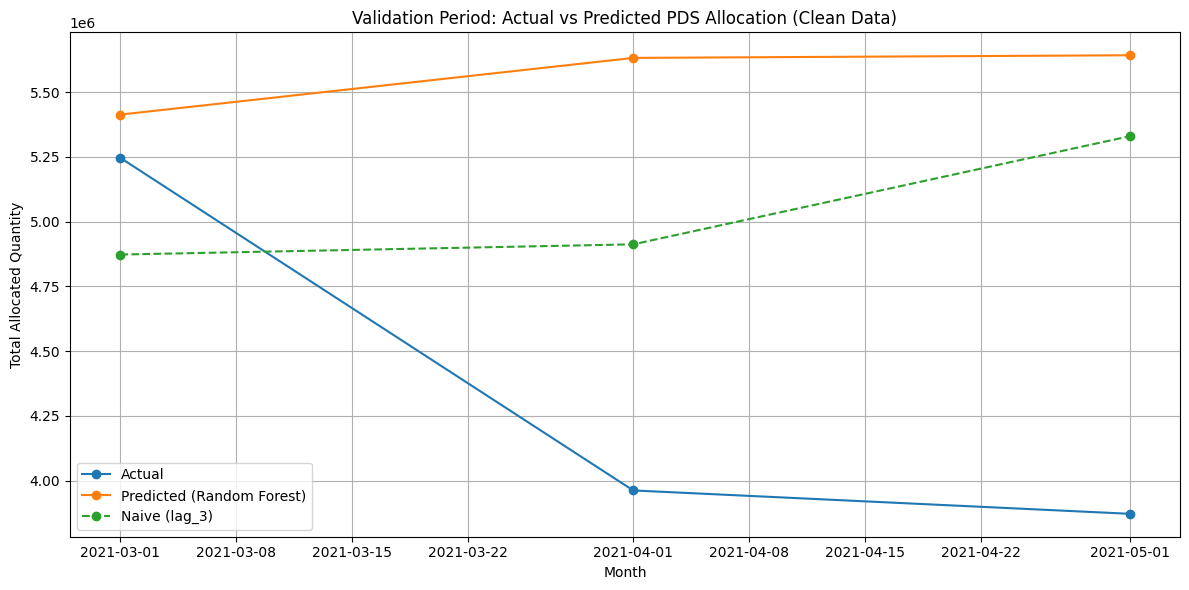

In [198]:
# PLOTTING THE VISUALISATION
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_results["date"],
    monthly_results["y_true"],
    marker="o",
    label="Actual"
)

plt.plot(
    monthly_results["date"],
    monthly_results["y_pred"],
    marker="o",
    label="Predicted (Random Forest)"
)

plt.plot(
    monthly_results["date"],
    monthly_results["y_naive"],
    marker="o",
    linestyle="--",
    label="Naive (lag_3)"
)

plt.title("Validation Period: Actual vs Predicted PDS Allocation (Clean Data)")
plt.xlabel("Month")
plt.ylabel("Total Allocated Quantity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [199]:
# --------------------------------------
# CHECKING FEATURE IMPORTANCES
# --------------------------------------

In [200]:
# Get numeric feature names (unchanged)
numeric_features = NUMERIC_FEATURES

# Get categorical feature names after one-hot encoding
ohe = rf_pipeline.named_steps["preprocessor"] \
                 .named_transformers_["cat"] \
                 .named_steps["onehot"]

categorical_feature_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)

# Combine all feature names
feature_names = np.concatenate([
    numeric_features,
    categorical_feature_names
])


In [201]:
len(feature_names)

42

In [202]:
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

In [203]:
feature_importance_df.head(15)

,feature,importance
0,lag_2,0.396430
1,rolling_mean_3,0.323671
2,state_uttar pradesh,0.134767
3,lag_1,0.073187
4,lag_3,0.042809
5,rolling_std_3,0.006542
6,state_karnataka,0.004439
7,month,0.004196
8,commodity_rice,0.004087
9,commodity_wheat,0.003613


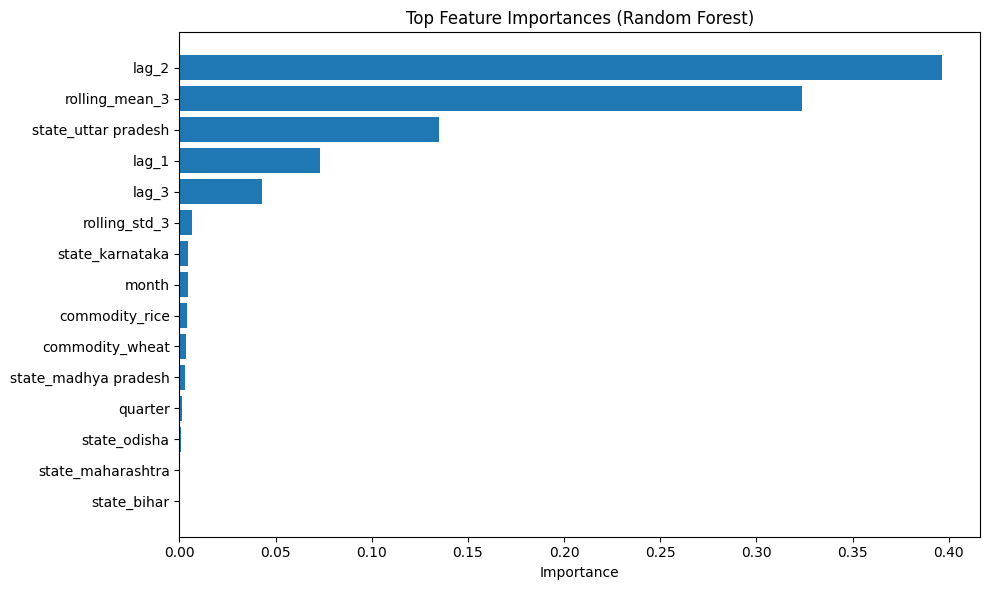

In [204]:
plt.figure(figsize=(10, 6))

top_n = 15
plt.barh(
    feature_importance_df["feature"][:top_n][::-1],
    feature_importance_df["importance"][:top_n][::-1]
)

plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [205]:
train_numeric = train_df[NUMERIC_FEATURES + [TARGET_COL]]

train_numeric.corr()[TARGET_COL].sort_values(ascending=False)

target            1.000000
rolling_mean_3    0.906313
lag_1             0.877850
lag_2             0.877553
lag_3             0.863298
rolling_std_3     0.338264
quarter           0.011701
month             0.010731
Name: target, dtype: float64

e:\Learning\Data Science\ML Project\pds_foodgrain_forecasting\penv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 6 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


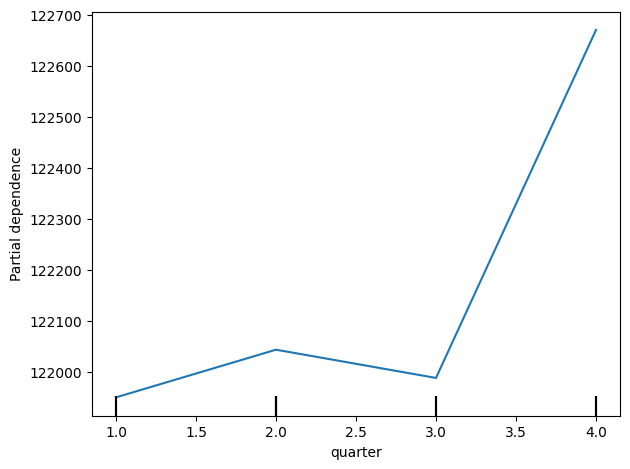

In [207]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    rf_pipeline,
    X_train,
    features=["quarter"],
    grid_resolution=12
)

plt.tight_layout()
plt.show()
